[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oalnaseri/mobilcom_course/blob/main/10_mimo_capacity_interactive.ipynb)

> **Run this notebook in Google Colab** — click the badge above (no local install needed).
> The setup cell below installs dependencies and enables interactive `ipywidgets` sliders in Colab.

---

# 📡 MIMO 2×2 — Why "Very Different" Channels Are the Whole Point
### Interactive Teaching Notebook — DHBW Mobile Communications
---
The lecture slide says the two data streams $\underline{x}_1$ and $\underline{x}_2$ can be
separated again **if the channels $\underline{h}_{ij}$ are "very different", e.g. in case of
strong multipath propagation**.

This notebook turns that sentence into a number. "Very different" means the channel matrix
$\mathbf{H}$ is **well conditioned**; when the paths become similar, $\mathbf{H}$ becomes
nearly singular and the second stream drowns — no matter how much power you add.

---

In [1]:
# ============================================================
#  COLAB / ENVIRONMENT SETUP  (safe to run locally too)
# ============================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # numpy + matplotlib ship with Colab; ensure ipywidgets is present
    !pip install -q ipywidgets

    # Required so ipywidgets sliders / interactive output render in Colab
    from google.colab import output
    output.enable_custom_widget_manager()

print("Environment ready.  IN_COLAB =", IN_COLAB)

Environment ready.  IN_COLAB = False


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#f5f5f5'
rng_global = np.random.default_rng(0)
print("Libraries loaded.")

Libraries loaded.


## 📚 Theory Reference

### The 2×2 system
$$\begin{pmatrix}\underline{y}_1\\ \underline{y}_2\end{pmatrix}
=\underbrace{\begin{pmatrix}\underline{h}_{11}&\underline{h}_{12}\\
\underline{h}_{21}&\underline{h}_{22}\end{pmatrix}}_{\mathbf{H}}
\begin{pmatrix}\underline{x}_1\\ \underline{x}_2\end{pmatrix}+
\begin{pmatrix}\underline{n}_1\\ \underline{n}_2\end{pmatrix}$$

Two equations, two unknowns — solvable **provided the two equations are independent**.

### Capacity
$$C=\log_2\det\!\left(\mathbf{I}+\frac{\mathrm{SNR}}{N_t}\mathbf{H}\mathbf{H}^H\right)
\quad\text{[bit/s/Hz]},\qquad
C_{SISO}=\log_2(1+\mathrm{SNR})$$

Using the singular values $\sigma_i$ of $\mathbf{H}$ this is
$$C=\sum_i\log_2\!\left(1+\frac{\mathrm{SNR}}{N_t}\sigma_i^2\right)$$
— i.e. MIMO opens $\min(N_t,N_r)$ **parallel pipes**, each with its own gain $\sigma_i^2$.

### "Very different" = well conditioned
$$\kappa=\frac{\sigma_{max}}{\sigma_{min}}$$
$\kappa\approx1$: two equally good pipes → the full factor-of-2 gain.
$\kappa\gg1$: the second pipe is nearly dead → back to SISO behaviour.

### Correlation
Antennas too close together, or a pure line-of-sight with no scatterers, make the
$h_{ij}$ similar. This is modelled by
$$\mathbf{H}=\mathbf{R}_{rx}^{1/2}\,\mathbf{H}_{iid}\,\mathbf{R}_{tx}^{1/2},
\qquad \mathbf{R}=\begin{pmatrix}1&\rho\\ \rho^*&1\end{pmatrix}$$

$\rho = 0$: rich scattering, ideal for MIMO.
$\rho \to 1$: the antennas see the same thing — spatial multiplexing fails.

> This is the deep irony of the subject: **multipath, the villain of slide set 1, is what
> makes MIMO work.**

---

In [3]:
# ---------------------------------------------------------------
#  CORE
# ---------------------------------------------------------------
def corr_sqrt(rho, n):
    """Matrix square root of the exponential correlation matrix R."""
    idx = np.arange(n)
    R   = rho ** np.abs(idx[:, None] - idx[None, :])
    w, V = np.linalg.eigh(R)
    return V @ np.diag(np.sqrt(np.maximum(w, 0))) @ V.conj().T

def rayleigh_H(Nt, Nr, n_real, rho_tx=0.0, rho_rx=0.0, K_dB=None, seed=0):
    """n_real realisations of the channel matrix (Nr x Nt)."""
    rng = np.random.default_rng(seed)
    Hi  = (rng.normal(size=(n_real, Nr, Nt)) +
           1j*rng.normal(size=(n_real, Nr, Nt)))/np.sqrt(2)
    if K_dB is not None:                       # add a rank-1 LOS component
        K   = 10**(K_dB/10)
        a_t = np.exp(1j*np.pi*np.arange(Nt)*0.5)
        a_r = np.exp(1j*np.pi*np.arange(Nr)*0.5)
        Hlos = np.outer(a_r, a_t.conj())
        Hi   = np.sqrt(K/(K+1))*Hlos + np.sqrt(1/(K+1))*Hi
    Rt = corr_sqrt(rho_tx, Nt); Rr = corr_sqrt(rho_rx, Nr)
    return Rr @ Hi @ Rt

def capacity(H, snr_dB):
    """Ergodic capacity [bit/s/Hz] for equal power allocation."""
    snr = 10**(np.asarray(snr_dB, float)/10.0)
    Nr, Nt = H.shape[-2], H.shape[-1]
    s = np.linalg.svd(H, compute_uv=False)          # (n_real, min(Nt,Nr))
    out = []
    for g in np.atleast_1d(snr):
        C = np.log2(1 + g/Nt*s**2).sum(axis=-1)
        out.append(C)
    out = np.array(out)
    return out[0] if np.isscalar(snr) or out.shape[0] == 1 else out

def condition_number(H):
    s = np.linalg.svd(H, compute_uv=False)
    return s[..., 0]/np.maximum(s[..., -1], 1e-12)

print("MIMO core ready.")

MIMO core ready.


In [4]:
# ---------------------------------------------------------------
#  ONE CONCRETE 2x2 CHANNEL, WORKED THROUGH
# ---------------------------------------------------------------
def normalise(H):
    """Scale so that the TOTAL channel power is the same in every example,
    which isolates the *shape* of H from its gain."""
    Nr, Nt = H.shape
    return H/np.linalg.norm(H)*np.sqrt(Nr*Nt)

H = normalise(rayleigh_H(2, 2, 1, seed=1)[0])
np.set_printoptions(precision=3, suppress=True)
print("Channel matrix H (rich scattering, rho = 0, normalised power):")
print(H)
s = np.linalg.svd(H, compute_uv=False)
print(f"\nsingular values      sigma = {s.round(3)}")
print(f"condition number     kappa = {s[0]/s[1]:.2f}   -> two usable, comparable 'pipes'")
for snr in (0, 10, 20):
    C2 = capacity(H[None], snr)[0]
    C1 = np.log2(1 + 10**(snr/10))
    print(f"SNR = {snr:2d} dB :  C(2x2) = {C2:5.2f} bit/s/Hz   "
          f"C(SISO) = {C1:5.2f}   gain x{C2/C1:.2f}")

# --- and now an almost-singular channel (strong LOS, no scatterers) -----
Hb = normalise(rayleigh_H(2, 2, 1, rho_tx=0.98, rho_rx=0.98, K_dB=15, seed=1)[0])
sb = np.linalg.svd(Hb, compute_uv=False)
print("\nSame total power, but rho = 0.98 and a 15 dB LOS component:")
print(f"singular values      sigma = {sb.round(3)}")
print(f"condition number     kappa = {sb[0]/sb[1]:.1f}   -> the second pipe is nearly dead")
for snr in (0, 10, 20):
    C2 = capacity(Hb[None], snr)[0]
    C1 = np.log2(1 + 10**(snr/10))
    print(f"SNR = {snr:2d} dB :  C(2x2) = {C2:5.2f} bit/s/Hz   "
          f"C(SISO) = {C1:5.2f}   gain x{C2/C1:.2f}")

Channel matrix H (rich scattering, rho = 0, normalised power):
[[ 0.335+0.879j  0.797+0.433j]
 [ 0.321-0.521j -1.265+0.564j]]

singular values      sigma = [1.809 0.853]
condition number     kappa = 2.12   -> two usable, comparable 'pipes'
SNR =  0 dB :  C(2x2) =  1.85 bit/s/Hz   C(SISO) =  1.00   gain x1.85
SNR = 10 dB :  C(2x2) =  6.33 bit/s/Hz   C(SISO) =  3.46   gain x1.83
SNR = 20 dB :  C(2x2) = 12.59 bit/s/Hz   C(SISO) =  6.66   gain x1.89

Same total power, but rho = 0.98 and a 15 dB LOS component:
singular values      sigma = [2.    0.002]
condition number     kappa = 895.7   -> the second pipe is nearly dead
SNR =  0 dB :  C(2x2) =  1.58 bit/s/Hz   C(SISO) =  1.00   gain x1.58
SNR = 10 dB :  C(2x2) =  4.39 bit/s/Hz   C(SISO) =  3.46   gain x1.27
SNR = 20 dB :  C(2x2) =  7.65 bit/s/Hz   C(SISO) =  6.66   gain x1.15


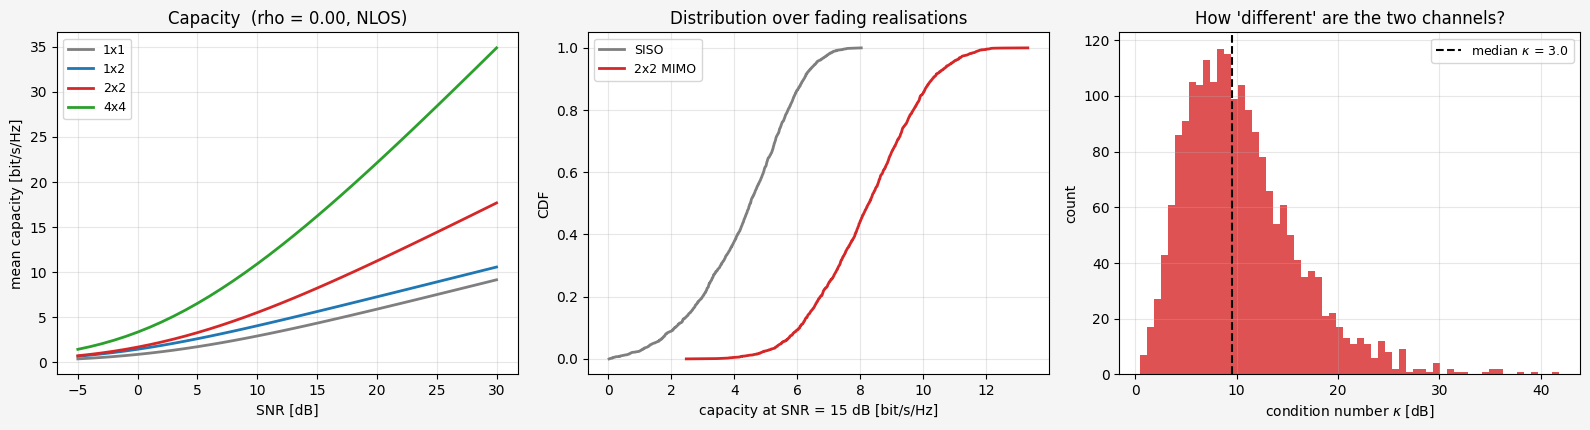

mean C(2x2) at 15 dB = 8.22 bit/s/Hz     mean C(SISO) = 4.33 bit/s/Hz     gain x1.90     median kappa = 3.0


In [5]:
# ---------------------------------------------------------------
#  CAPACITY CURVES
# ---------------------------------------------------------------
def plot_mimo(rho=0.0, K_dB=None, n_real=2000, seed=1):
    snr = np.arange(-5, 31, 1.0)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

    # 1) mean capacity vs SNR for several array sizes
    for (Nt, Nr), col in zip([(1,1), (1,2), (2,2), (4,4)],
                             ['C7','C0','C3','C2']):
        H = rayleigh_H(Nt, Nr, n_real, rho, rho, K_dB, seed)
        C = capacity(H, snr).mean(axis=1)
        ax[0].plot(snr, C, lw=2, color=col, label=f"{Nt}x{Nr}")
    ax[0].set_xlabel("SNR [dB]"); ax[0].set_ylabel("mean capacity [bit/s/Hz]")
    ax[0].set_title(f"Capacity  (rho = {rho:.2f}"
                    + (f", K = {K_dB:.0f} dB)" if K_dB is not None else ", NLOS)"))
    ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

    # 2) capacity CDF at 15 dB
    H = rayleigh_H(2, 2, n_real, rho, rho, K_dB, seed)
    C22 = capacity(H, 15.0)[0] if capacity(H, 15.0).ndim > 1 else capacity(H, 15.0)
    C22 = np.atleast_1d(C22).ravel()
    Hs  = rayleigh_H(1, 1, n_real, 0, 0, K_dB, seed)
    C11 = np.atleast_1d(capacity(Hs, 15.0)).ravel()
    for C, lab, col in [(C11, 'SISO', 'C7'), (C22, '2x2 MIMO', 'C3')]:
        ax[1].plot(np.sort(C), np.linspace(0, 1, C.size), lw=2, color=col, label=lab)
    ax[1].set_xlabel("capacity at SNR = 15 dB [bit/s/Hz]")
    ax[1].set_ylabel("CDF"); ax[1].set_title("Distribution over fading realisations")
    ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

    # 3) condition number histogram
    k = condition_number(H)
    ax[2].hist(20*np.log10(k), bins=60, color='C3', alpha=.8)
    ax[2].axvline(20*np.log10(np.median(k)), color='k', ls='--',
                  label=f"median $\\kappa$ = {np.median(k):.1f}")
    ax[2].set_xlabel(r"condition number $\kappa$ [dB]")
    ax[2].set_ylabel("count")
    ax[2].set_title(r"How 'different' are the two channels?")
    ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)

    fig.tight_layout(); plt.show()
    print(f"mean C(2x2) at 15 dB = {C22.mean():.2f} bit/s/Hz     "
          f"mean C(SISO) = {C11.mean():.2f} bit/s/Hz     "
          f"gain x{C22.mean()/C11.mean():.2f}     median kappa = {np.median(k):.1f}")

plot_mimo(rho=0.0)

In [6]:
# ---------------------------------------------------------------
#  INTERACTIVE
# ---------------------------------------------------------------
style  = {'description_width': '215px'}
layout = widgets.Layout(width='560px')

sl_rho = widgets.FloatSlider(value=0.0, min=0.0, max=0.98, step=0.02,
            description='antenna correlation rho:', style=style, layout=layout)
tg_los = widgets.ToggleButtons(options=[('NLOS (rich scattering)', False),
                                        ('LOS present', True)],
            value=False, description='scenario:', style=style)
sl_K   = widgets.FloatSlider(value=10, min=-10, max=25, step=1,
            description='Rice factor K [dB]:', style=style, layout=layout)
sl_n   = widgets.IntSlider(value=2000, min=200, max=6000, step=200,
            description='realisations:', style=style, layout=layout)

def update(rho, los, K, n):
    plot_mimo(rho=rho, K_dB=(K if los else None), n_real=n)

ui  = widgets.VBox([sl_rho, tg_los, sl_K, sl_n])
out = widgets.interactive_output(update, {'rho': sl_rho, 'los': tg_los,
                                          'K': sl_K, 'n': sl_n})
display(ui, out)

Output()

## 📝 Try this

1. **Start at $\rho = 0$.** At 15 dB SNR the 2×2 capacity should be roughly twice the SISO
   value — the "factor of 2" the slide promises. Note the median condition number: small.
2. **Now raise $\rho$ towards 0.98.** Watch the 2×2 curve collapse towards the SISO curve
   while the condition-number histogram slides to the right. Nothing about the *power*
   changed — only how *different* the four channels are. That is exactly the sentence on
   the lecture slide, measured.
3. **Switch on LOS and raise $K$ to 20 dB.** Capacity *drops*, which surprises everybody
   the first time. A strong direct path makes $\mathbf{H}$ nearly rank-1: great for a
   link budget, terrible for spatial multiplexing. This is why the slide recommends
   **polarisation** multiplexing for line-of-sight links — two orthogonal polarisations
   stay independent even without scatterers.
4. **Look at the CDF panel.** MIMO does not only raise the mean; it makes the *low* end
   much less likely. That is diversity, and it is often worth more than the extra bits.
5. **Try 4×4.** The gain is roughly ×4 at high SNR — but only in rich scattering. Now
   remember the slide's remark that 8×8 in a handset is limited by *space* and *battery*,
   not by information theory.

## 📌 Summary

| | rich scattering (NLOS) | strong LOS / correlated antennas |
|---|---|---|
| $\mathbf{H}$ | well conditioned, $\kappa\approx1$ | nearly singular, $\kappa\gg1$ |
| spatial multiplexing | works, ×$\min(N_t,N_r)$ | fails |
| better strategy | spatial multiplexing | polarisation multiplexing / beamforming |

**Multipath is not noise. For MIMO it is the resource.**